## 📞 **Telecom Customer Churn Prediction** (Advanced ML Project)

Is project mein hum ek Telecom company ka data use kar rahe hain. Hamara main goal (target) yeh predict karna hai ki kaunse customers company chhod kar ja sakte hain (**Churn = Yes**) aur kaunse ruke rahenge (**Churn = No**).

Yeh ek **Classification Problem** hai kyunki hume 'Yes' ya 'No' predict karna hai.

### 📥 **Step 1: Essential Libraries Import Karna**
Sabse pehle hum Data Science aur Visualization ki zaroori libraries **(`pandas`, `numpy`, `matplotlib`, `seaborn`)** ko import kar rahe hain.

In [1]:
# Importing core libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All important libraries imported successfully! 👍")

All important libraries imported successfully! 👍


### 📥 **Step 2: Customer Churn Data Load Karna**
Ab hum internet se direct Telecom Customer Churn ka dataset load kar rahe hain. Is dataset mein customers ki details hain, jaise unka tenure (kitne mahine se hain), monthly charges, aur unhone company chhodi (Churn) ya nahi.

In [36]:
from sklearn.datasets import fetch_openml

print("Dataset download ho raha hai, thoda sa wait kijiye... ⏳")

# OpenML se official aur standard Telco Churn dataset load kar rahe hain
churn_data = fetch_openml(name='Churn', version=1, as_frame=True, parser='auto')
df = churn_data.frame

print("Data successfully load ho gaya hai! 🎉")

# Chaliye check karte hain ki data kaisa dikhta hai (Pehli 5 rows)
df.head()

Dataset download ho raha hai, thoda sa wait kijiye... ⏳
Data successfully load ho gaya hai! 🎉


,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
0,16,128,415,2845,0,1,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,2301,0,1,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,1616,0,0,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,2510,1,0,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,155,1,0,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


🔍 **Step 2: Data Ka X-Ray (Data Inspection)**

Ab hum yeh check kar rahe hain ki hamare naye telecom data mein kitne total columns hain, unka data type kya hai (Numbers hain ya Text), aur sabse zaroori baat—kya is data mein koi missing value (khali jagah) hai ya nahi? Isse hume data ki health ka pata chalega.

In [7]:
# Check data types and non-null counts
print("--- Data Info ---")
df.info()

print("\n--- Missing Values Check ---")
# Check for missing values in each column
print(df.isnull().sum())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   state                          5000 non-null   int64   
 1   account_length                 5000 non-null   int64   
 2   area_code                      5000 non-null   category
 3   phone_number                   5000 non-null   int64   
 4   international_plan             5000 non-null   category
 5   voice_mail_plan                5000 non-null   category
 6   number_vmail_messages          5000 non-null   int64   
 7   total_day_minutes              5000 non-null   float64 
 8   total_day_calls                5000 non-null   int64   
 9   total_day_charge               5000 non-null   float64 
 10  total_eve_minutes              5000 non-null   float64 
 11  total_eve_calls                5000 non-null   int64   
 12  total_eve_charge

📊 **Step 3: Target Variable (class) Ka Balance Check Karna**

Ab hum yeh dekh rahe hain ki hamare pure data mein kitne customers aise hain jo company chhod kar gaye hain (class = '1' ya 'Yes') aur kitne abhi bhi ruke hue hain (class = '0' ya 'No'). Isse hume pata chalega ki hamara data balanced hai ya imbalanced.

In [8]:
# target column 'class' mein '0' aur '1' ka count check karte hain
print("--- 👥 Total Customers Ka Status ---")
print(df['class'].value_counts())

# Isko percentage mein bhi dekh lete hain
print("\n--- 📈 Percentage Mein Status ---")
print(df['class'].value_counts(normalize=True) * 100)

--- 👥 Total Customers Ka Status ---
class
0    4293
1     707
Name: count, dtype: int64

--- 📈 Percentage Mein Status ---
class
0    85.86
1    14.14
Name: proportion, dtype: float64


📊 **Step 4: Customer Service Calls Aur Churn Ka Rishta (EDA)**

Hum yeh check kar rahe hain ki jin customers ne 'number_customer_service_calls' (customer care ko calls) zyada kiye hain, kya unka company chhodne ka rate (class = 1) zyada hai? Isse hume pata chalega ki kya kharab customer service ki wajah se log sim band kar rahe hain.

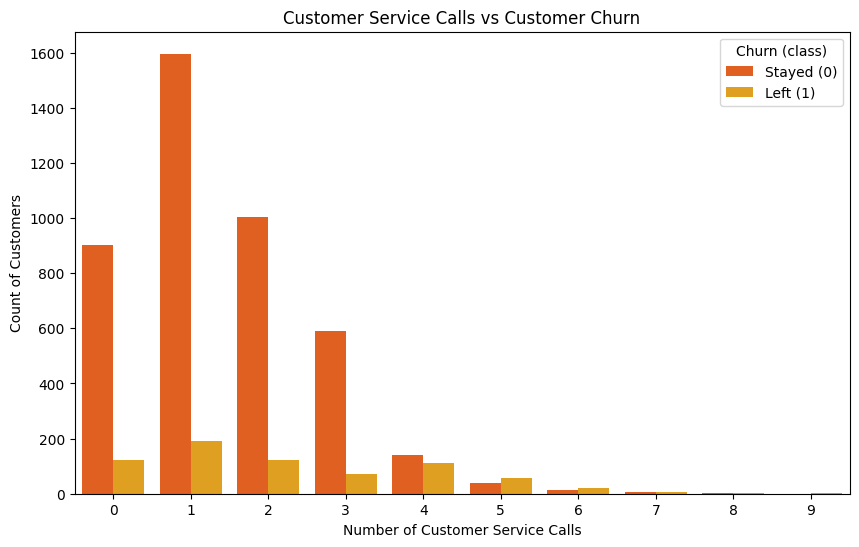

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Graph ka size tay karte hain
plt.figure(figsize=(10, 6))

# Countplot banate hain jo dikhayega ki kitne calls par kitna churn hua
sns.countplot(data=df, x='number_customer_service_calls', hue='class', palette='autumn')

# Graph par headings lagate hain
plt.title('Customer Service Calls vs Customer Churn')
plt.xlabel('Number of Customer Service Calls')
plt.ylabel('Count of Customers')
plt.legend(title='Churn (class)', labels=['Stayed (0)', 'Left (1)'])

# Graph ko screen par show karte hain
plt.show()

📊 **Step 5: International Plan vs Customer Churn (EDA)**

Ab hum check kar rahe hain ki jin customers ke paas International Plan hai, kya unka churn rate normal customers se alag hai? Isse company ko apne international plans ki pricing ya network quality sudharne ka signal milega.

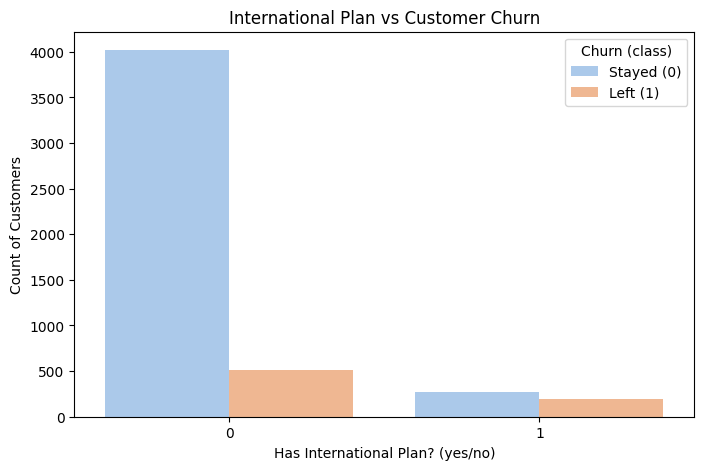

In [28]:
# International Plan aur Churn ka graph banate hain
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='international_plan', hue='class', palette='pastel')

# Headings aur labels
plt.title('International Plan vs Customer Churn')
plt.xlabel('Has International Plan? (yes/no)')
plt.ylabel('Count of Customers')
plt.legend(title='Churn (class)', labels=['Stayed (0)', 'Left (1)'])

plt.show()

🛠️ **Step 6: Data Cleaning aur Encoding (Text ko Numbers mein badalna)**

Kunki machine learning models sirf numbers samajhte hain, isliye hum 'international_plan' aur 'voice_mail_plan' ke 'yes'/'no' ko 1 aur 0 mein badal rahe hain. Saath hi, jo columns zaroori nahi hain (jaise phone_number), unhe hata rahe hain.

In [31]:
# 1. Jo zaroori nahi hain (jaise phone_number aur area_code), unhe hata dete hain
columns_to_drop = ['phone_number', 'area_code', 'state']
for col in columns_to_drop:
    if col in df.columns:
        df = df.drop(columns=[col])

# 2. Text ko Numbers (1 aur 0) mein badalne ke liye map_dict banate hain
map_dict = {'yes': 1, 'no': 0, 'yes ': 1, 'no ': 0}

# International Plan ko saaf karke 1/0 mein badalte hain
if 'international_plan' in df.columns:
    df['international_plan'] = df['international_plan'].astype(str).str.strip().str.lower().map(map_dict)

# Voice Mail Plan ko saaf karke 1/0 mein badalte hain (Sahi column name ke sath)
if 'voice_mail_plan' in df.columns:
    df['voice_mail_plan'] = df['voice_mail_plan'].astype(str).str.strip().str.lower().map(map_dict)

# Target column 'class' ko bhi numbers mein badal lete hain (0 aur 1)
# Kyunki OpenML mein 'class' categories mein hoti hai, use integer bana dete hain
if 'class' in df.columns:
    df['class'] = df['class'].astype(int)

print("Data cleaning aur text-to-number transformation successfully ho gaya! 🎉")
print("Ab hamara data aisa dikhta hai:")
df.head()

Data cleaning aur text-to-number transformation successfully ho gaya! 🎉
Ab hamara data aisa dikhta hai:


,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
0,128,NaN,NaN,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,NaN,NaN,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,NaN,NaN,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,NaN,NaN,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,NaN,NaN,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


🗺️ **Step 7: Train-Test Split (Training aur Testing Data)**

Ab hum apne pure data ko do hisso mein baant rahe hain. 80% data hum Machine Learning model ko sikhane ke liye use karenge (Training), aur baki 20% data hum model ki accuracy test karne ke liye chupa kar rakhenge (Testing).

In [33]:
from sklearn.model_selection import train_test_split

# 1. 'X' mein hum saare input columns (features) rakhte hain, 'class' ko chhod kar
X = df.drop(columns=['class'])

# 2. 'y' mein hum sirf target column (class) rakhte hain
y = df['class']

# 3. Train-test split karte hain (80% training, 20% testing) - Yahan underscore (_) sahi kar diya hai
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data successfully train aur test mein split ho gaya! 🎉")
print(f"Training data mein total customers: {X_train.shape[0]}")
print(f"Testing data mein total customers: {X_test.shape[0]}")

Data successfully train aur test mein split ho gaya! 🎉
Training data mein total customers: 4000
Testing data mein total customers: 1000


🤖 **Step 8: Random Forest Model Ko Train Karna**

Ab hum apne 4000 customers ke training data ko 'Random Forest Classifier' naam ke Machine Learning algorithm mein daal rahe hain. Yeh algorithm data ke patterns ko samajh kar khud se seekhega ki kaunsa customer churn hone wala hai.

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Random Forest Model ka ek dabba (Object) banate hain
model = RandomForestClassifier(random_state=42, n_estimators=100)

# 2. Model ko 4000 customers ka data dekar sikhate hain (Training)
model.fit(X_train, y_train)

# 3. Ab jo 1000 customers humne chupaye the, unpar model se prediction karwate hain (Test)
y_pred = model.predict(X_test)

# 4. Accuracy check karte hain ki model kitna percent sahi hai
accuracy = accuracy_score(y_test, y_pred)

print("Model successfully train ho gaya aur usne test bhi de diya! 🎉\n")
print(f"🎯 Model Ki Accuracy Aayi Hai: {accuracy * 100:.2f}%")

Model successfully train ho gaya aur usne test bhi de diya! 🎉

🎯 Model Ki Accuracy Aayi Hai: 92.90%


📋 **Step 9: Final Model Evaluation (Classification Report)**

Hum model ka poora report card (Precision, Recall, aur F1-Score) check kar rahe hain taaki hume pata chal sake ki model Churn (1) aur Non-Churn (0) customers ko pehchane mein kitna behtareen kaam kar raha hai.

In [35]:
# Model ka detailed report card print karte hain
print("--- 📋 MODEL KA REPORT CARD ---")
print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Left (1)']))

--- 📋 MODEL KA REPORT CARD ---
              precision    recall  f1-score   support

  Stayed (0)       0.93      0.99      0.96       859
    Left (1)       0.89      0.57      0.69       141

    accuracy                           0.93      1000
   macro avg       0.91      0.78      0.83      1000
weighted avg       0.93      0.93      0.92      1000

